
# 📊 Exploratory Data Analysis (EDA)

## Student Performance Dataset

Variables :

- student_id
- attendance_pct
- absence_hours
- homework_pct
- study_hours_per_week
- midterm_score
- informatique
- mathematique
- svt
- physique
- sport
- education_islamique
- francais
- arabe
- pass


In [20]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,5)

from IPython.display import display

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load Dataset

In [21]:

df = pd.read_csv("data.csv", sep=";", encoding="utf-8")

# Clean column names and force numeric types
df.columns = df.columns.str.strip()
for col in df.columns:
    if col != "student_id":
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (1467, 15)
Columns: ['student_id', 'attendance_pct', 'absence_hours', 'homework_pct', 'study_hours_per_week', 'midterm_score', 'informatique', 'mathematique', 'svt', 'physique', 'sport', 'education_islamique', 'francais', 'arabe', 'pass']


,student_id,attendance_pct,absence_hours,homework_pct,study_hours_per_week,midterm_score,informatique,mathematique,svt,physique,sport,education_islamique,francais,arabe,pass
0,1,95,4,92,12,88,90,85,84,89,95,92,86,88,1
1,2,88,10,85,10,79,82,76,78,80,90,85,75,81,1
2,3,60,35,55,4,58,55,42,62,48,75,65,58,56,0
3,4,72,22,70,6,65,68,62,66,64,80,72,63,65,1
4,5,40,55,45,3,50,48,35,52,40,70,60,50,48,0


## 2. Dataset Overview

In [22]:

display(df.info())

display(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            1467 non-null   int64
 1   attendance_pct        1467 non-null   int64
 2   absence_hours         1467 non-null   int64
 3   homework_pct          1467 non-null   int64
 4   study_hours_per_week  1467 non-null   int64
 5   midterm_score         1467 non-null   int64
 6   informatique          1467 non-null   int64
 7   mathematique          1467 non-null   int64
 8   svt                   1467 non-null   int64
 9   physique              1467 non-null   int64
 10  sport                 1467 non-null   int64
 11  education_islamique   1467 non-null   int64
 12  francais              1467 non-null   int64
 13  arabe                 1467 non-null   int64
 14  pass                  1467 non-null   int64
dtypes: int64(15)
memory usage: 172.0 KB


None

,student_id,attendance_pct,absence_hours,homework_pct,study_hours_per_week,midterm_score,informatique,mathematique,svt,physique,sport,education_islamique,francais,arabe,pass
count,1467.000000,1467.00000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000,1467.000000
mean,734.000000,69.99591,26.014315,69.561691,7.347648,69.267212,69.362645,62.114519,70.507839,65.578050,82.064076,75.276755,67.276074,67.719155,0.601227
std,423.630735,17.44854,16.391291,16.948465,3.619778,14.970030,17.006320,18.423226,14.536510,16.872845,8.976701,12.761471,14.308127,15.424248,0.489813
min,1.000000,30.00000,4.000000,35.000000,2.000000,42.000000,38.000000,28.000000,45.000000,32.000000,65.000000,52.000000,11.000000,40.000000,0.000000
25%,367.500000,55.00000,11.000000,55.500000,4.000000,56.000000,54.000000,45.000000,58.000000,51.000000,74.000000,64.000000,55.000000,54.000000,0.000000
50%,734.000000,74.00000,21.000000,72.000000,7.000000,69.000000,71.000000,65.000000,70.000000,67.000000,82.000000,75.000000,67.000000,68.000000,1.000000
75%,1100.500000,86.00000,40.000000,85.000000,10.000000,83.000000,85.000000,79.000000,84.000000,81.000000,90.000000,87.000000,81.000000,82.000000,1.000000
max,1467.000000,95.00000,68.000000,96.000000,15.000000,97.000000,98.000000,92.000000,96.000000,94.000000,97.000000,97.000000,93.000000,95.000000,1.000000


## 3. Missing Values

In [23]:

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing Count", ascending=False)


,Missing Count,Missing %
student_id,0,0.0
attendance_pct,0,0.0
absence_hours,0,0.0
homework_pct,0,0.0
study_hours_per_week,0,0.0
midterm_score,0,0.0
informatique,0,0.0
mathematique,0,0.0
svt,0,0.0
physique,0,0.0


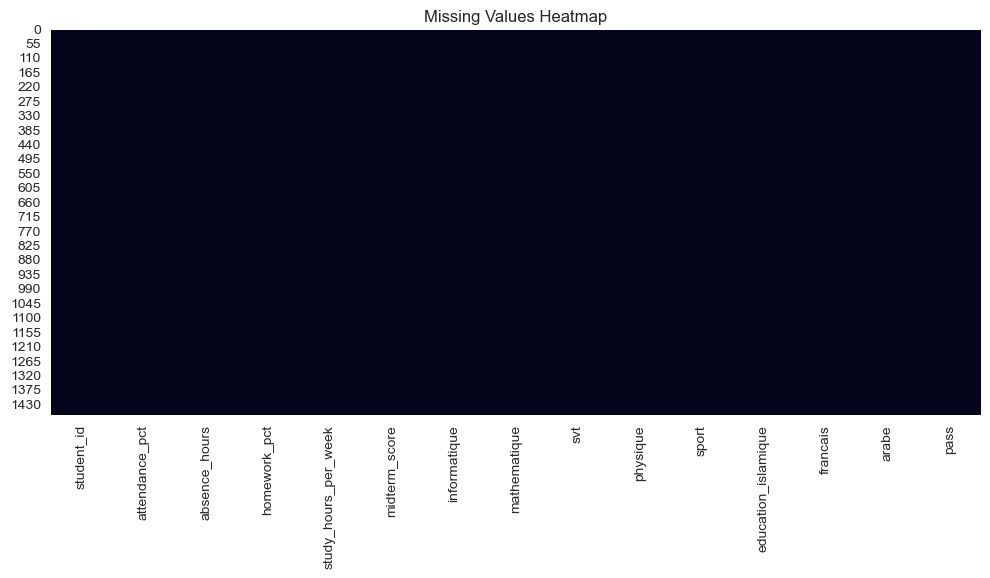

In [24]:

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


## 4. Target Variable Analysis

In [25]:

df["pass"].value_counts()


pass
1    882
0    585
Name: count, dtype: int64

## 5. Numerical Variables Distribution

In [26]:

num_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in ["student_id", "pass"]:
    if col in num_cols:
        num_cols.remove(col)

num_cols


['attendance_pct',
 'absence_hours',
 'homework_pct',
 'study_hours_per_week',
 'midterm_score',
 'informatique',
 'mathematique',
 'svt',
 'physique',
 'sport',
 'education_islamique',
 'francais',
 'arabe']

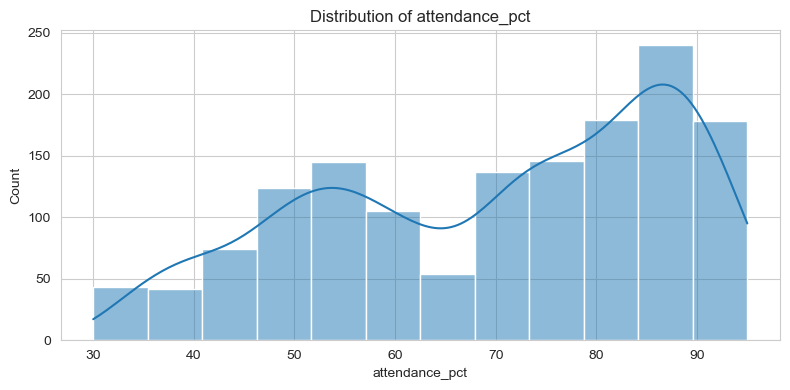

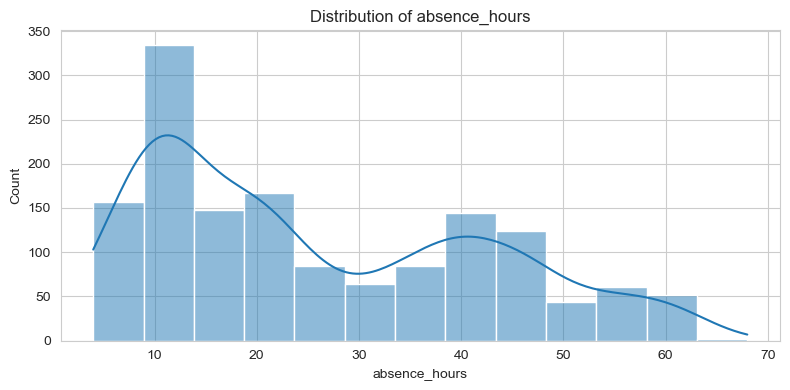

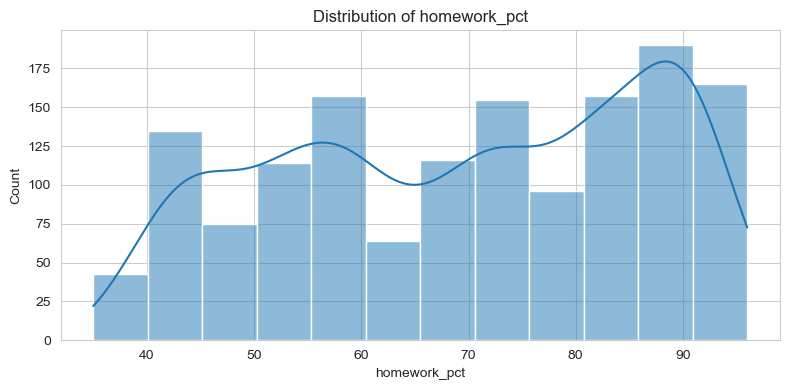

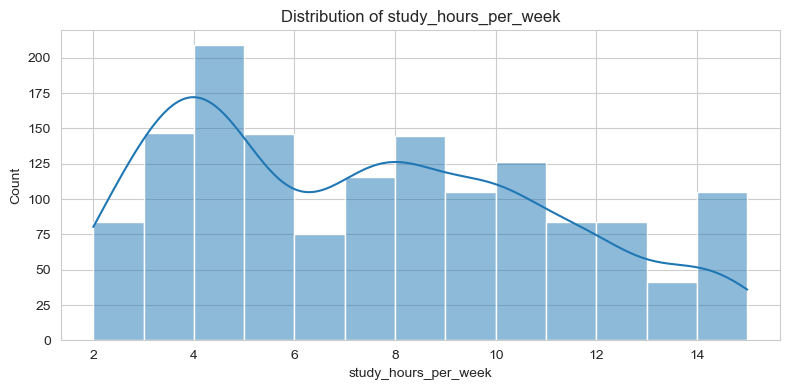

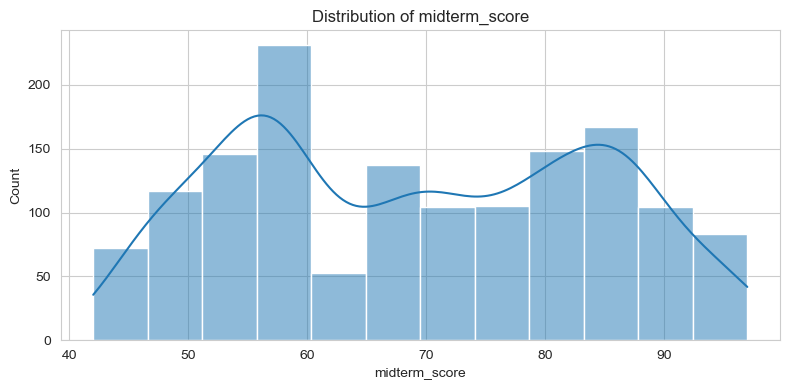

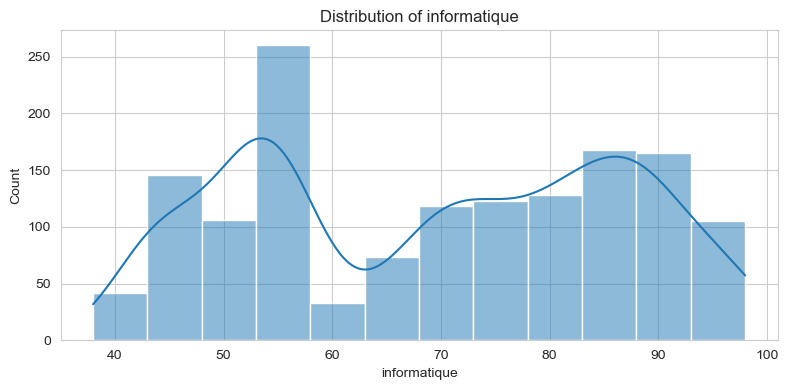

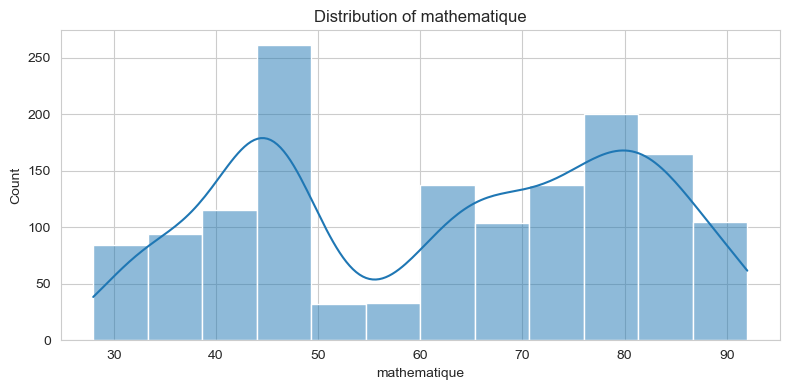

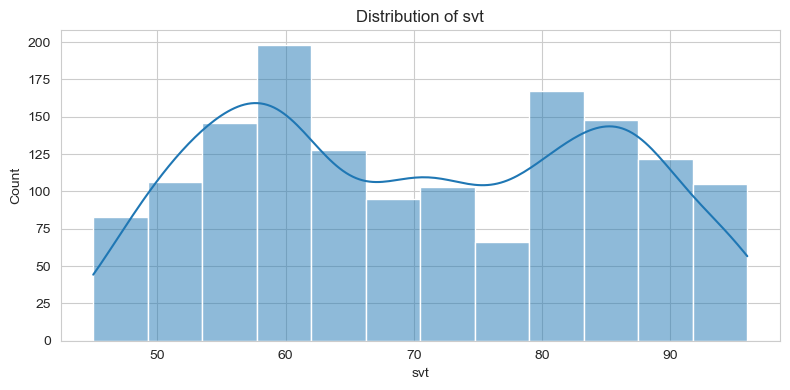

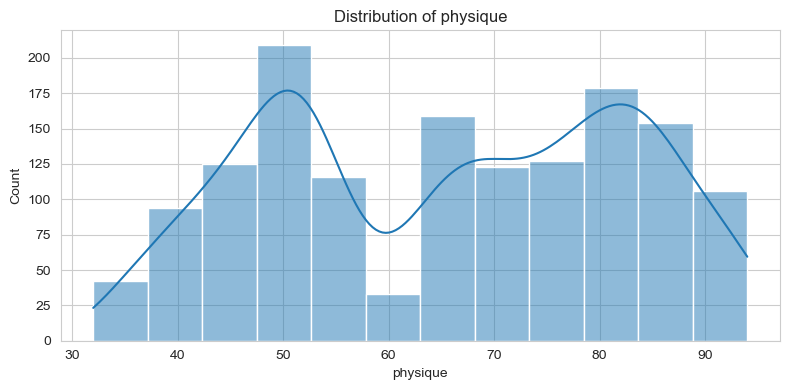

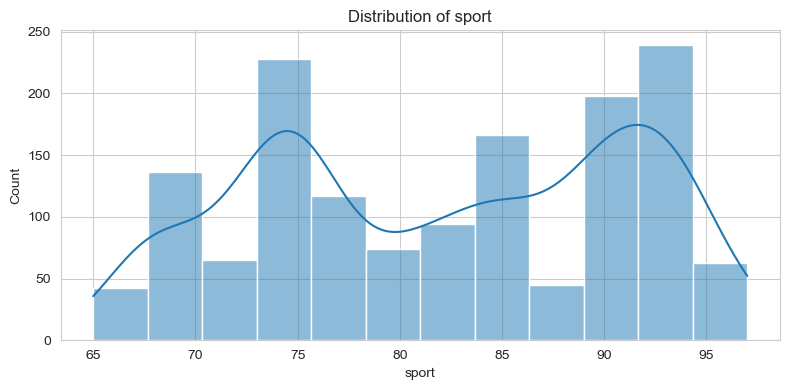

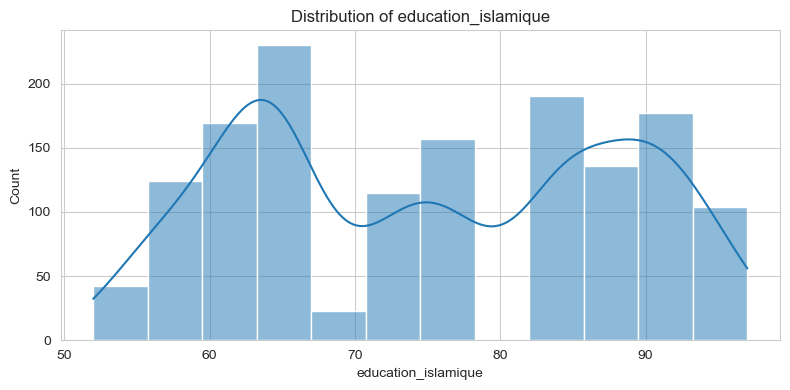

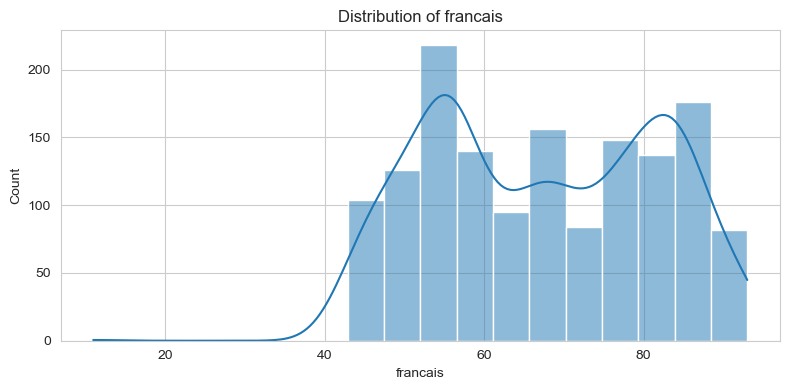

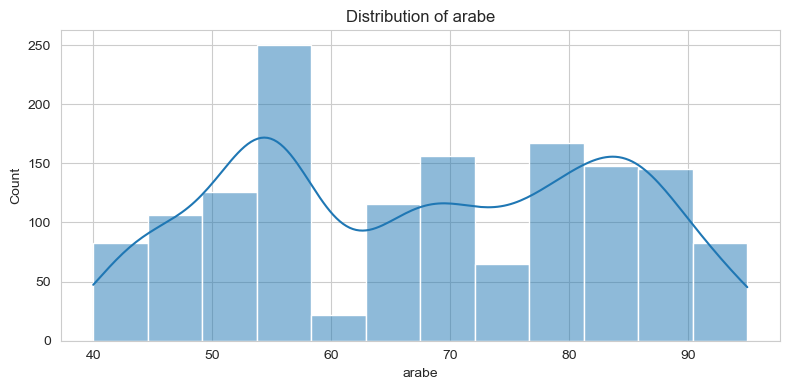

In [27]:

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


## 6. Outlier Detection (IQR)

In [28]:

outlier_summary = []

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary.append([col, outliers])

pd.DataFrame(
    outlier_summary,
    columns=["Feature","Outliers"]
).sort_values("Outliers", ascending=False)


,Feature,Outliers
11,francais,1
0,attendance_pct,0
1,absence_hours,0
2,homework_pct,0
3,study_hours_per_week,0
4,midterm_score,0
5,informatique,0
6,mathematique,0
7,svt,0
8,physique,0


## 7. Correlation Analysis

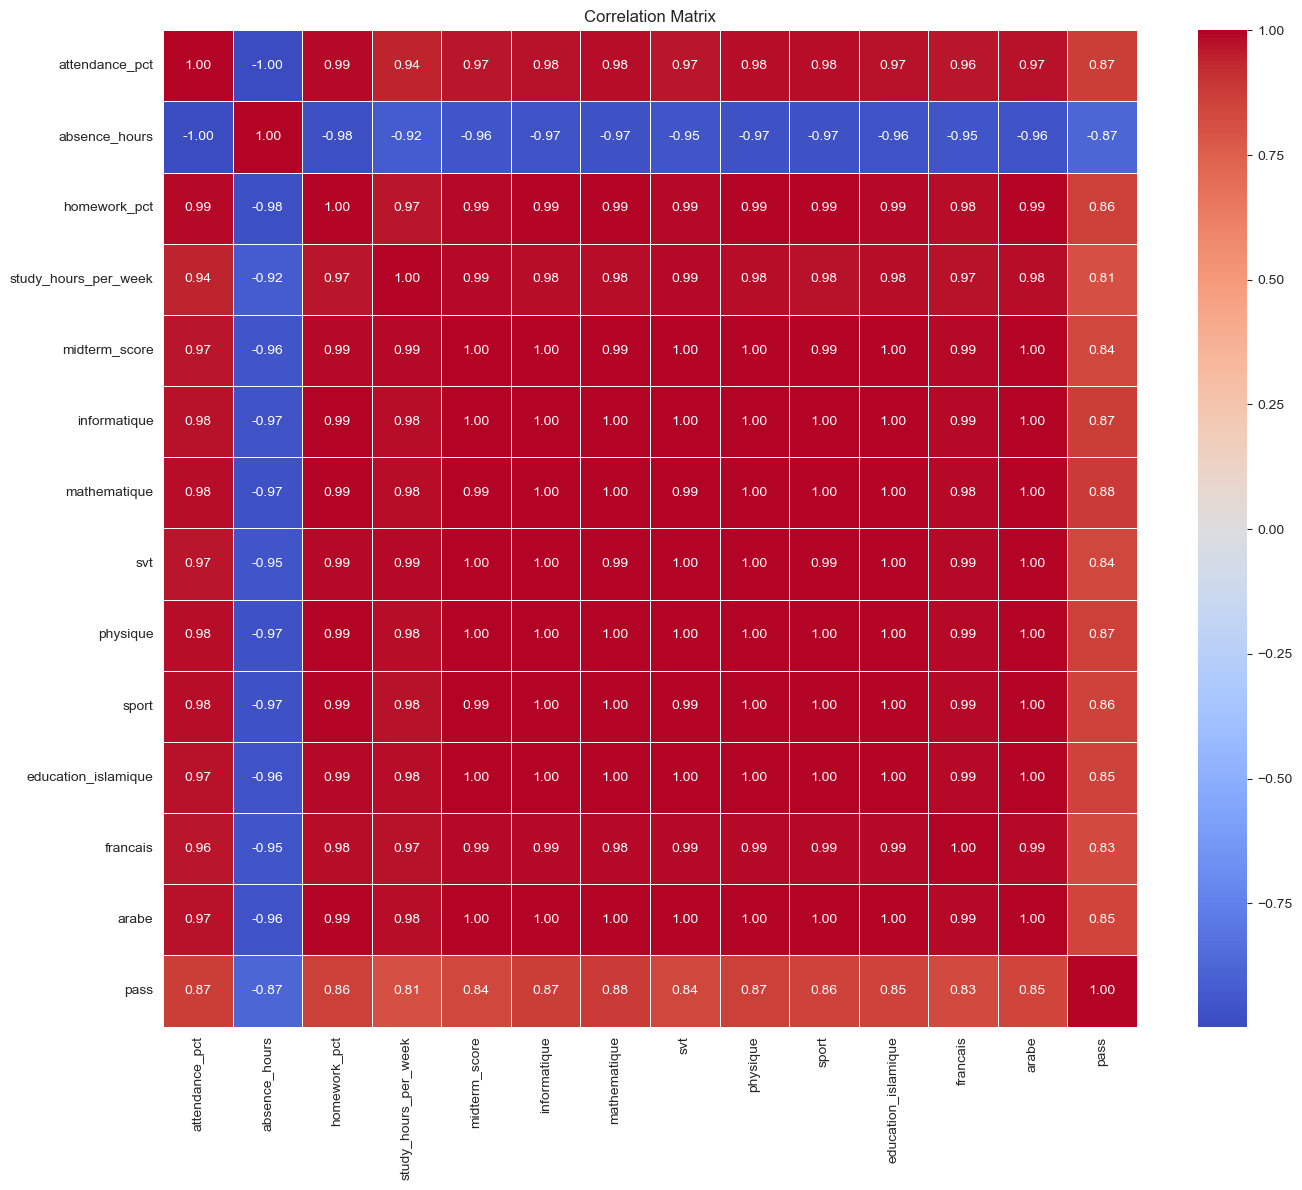

In [29]:

corr_cols = num_cols + ["pass"]
corr = df[corr_cols].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 13. Rapport d'Efficacité — Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    log_loss, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Prepare data ---
feature_cols = num_cols  # all numeric cols except student_id and pass
X = df[feature_cols].dropna()
y = df.loc[X.index, "pass"]

# --- Train/Test split (80/20) ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Pipeline: Scaler + Logistic Regression ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

# --- K-Fold Cross Validation (k=5) ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

j_train_list, j_cv_list, acc_list = [], [], []

for train_idx, val_idx in kf.split(X_train, y_train):
    Xtr, Xval = X_train.iloc[train_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[train_idx], y_train.iloc[val_idx]
    pipe.fit(Xtr, ytr)
    j_train_list.append(log_loss(ytr,  pipe.predict_proba(Xtr)))
    j_cv_list.append(log_loss(yval, pipe.predict_proba(Xval)))
    acc_list.append(accuracy_score(yval, pipe.predict(Xval)))

j_train_kfolds = np.mean(j_train_list)
j_cv_kfolds    = np.mean(j_cv_list)
accuracy_cv    = np.mean(acc_list)
pourcentage_erreur_cv = (1 - accuracy_cv) * 100

# --- Train final model on full train set, evaluate on test set ---
pipe.fit(X_train, y_train)
j_global = log_loss(y, pipe.predict_proba(X))
y_pred   = pipe.predict(X_test)
formatted_report = classification_report(y_test, y_pred,
    target_names=["Fail (0)", "Pass (1)"])

# --- Print Report ---
print(" RAPPORT D'EFFICACITÉ DE L'ALGORITHME (LOGISTIC REGRESSION)")
print("============================================================")
print(f"🎯 J GLOBAL  (Fonction de Coût Totale  - LogLoss) : {j_global:.4f}")
print(f"🔹 J_train   (Coût d'Entraînement Moyen - LogLoss) : {j_train_kfolds:.4f}")
print(f"🔹 J_CV      (Coût de Validation Croisée - LogLoss) : {j_cv_kfolds:.4f}")
print("------------------------------------------------------------")
print(f"📈 Taux de Précision Globale (CV Accuracy)          : {accuracy_cv * 100:.2f}%")
print(f"❌ Pourcentage d'Erreur Générale de l'IA             : {pourcentage_erreur_cv:.2f}%")
print("============================================================")
print(" MATRICE ET MÉTRIQUES DÉTAILLÉES (SUR LE JEU DE TEST EXTÉRIEUR) :")
print(formatted_report)


 RAPPORT D'EFFICACITÉ DE L'ALGORITHME (LOGISTIC REGRESSION)
🎯 J GLOBAL  (Fonction de Coût Totale  - LogLoss) : 0.0780
🔹 J_train   (Coût d'Entraînement Moyen - LogLoss) : 0.0799
🔹 J_CV      (Coût de Validation Croisée - LogLoss) : 0.0838
------------------------------------------------------------
📈 Taux de Précision Globale (CV Accuracy)          : 98.98%
❌ Pourcentage d'Erreur Générale de l'IA             : 1.02%
 MATRICE ET MÉTRIQUES DÉTAILLÉES (SUR LE JEU DE TEST EXTÉRIEUR) :
              precision    recall  f1-score   support

    Fail (0)       0.97      1.00      0.99       117
    Pass (1)       1.00      0.98      0.99       177

    accuracy                           0.99       294
   macro avg       0.99      0.99      0.99       294
weighted avg       0.99      0.99      0.99       294



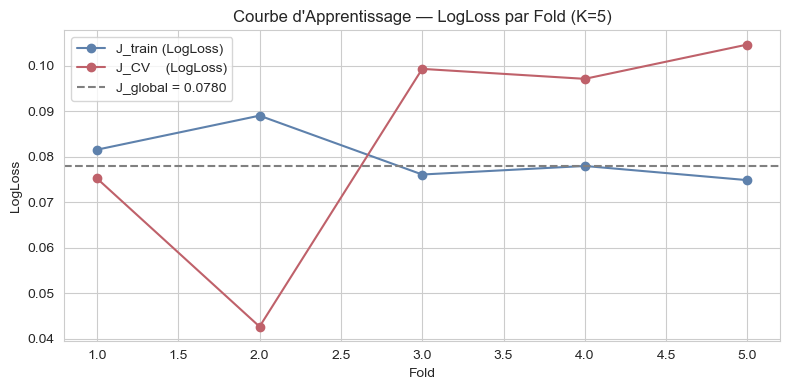

In [38]:
# --- Learning Curve (J_train vs J_CV) ---
fold_nums = list(range(1, len(j_train_list) + 1))

plt.figure(figsize=(8, 4))
plt.plot(fold_nums, j_train_list, "o-", label="J_train (LogLoss)", color="#5e81ac")
plt.plot(fold_nums, j_cv_list,    "o-", label="J_CV    (LogLoss)", color="#bf616a")
plt.axhline(j_global, linestyle="--", color="gray", label=f"J_global = {j_global:.4f}")
plt.xlabel("Fold")
plt.ylabel("LogLoss")
plt.title("Courbe d'Apprentissage — LogLoss par Fold (K=5)")
plt.legend()
plt.tight_layout()
plt.show()
